<center><h1>TP 4: Réseaux de Neurones Convolutifs- Optimsation et regularisation</h1></center>

## Avant de commencer le TP,
- vérifiez que vous êtes sur un environnement GPU et python 3 :
  
  Éxecution -> Modifier le type d'éxecution -> Type d'éxecution = python3, Accélerateur matériel = GPU

- Fichier -> Sauvegarder une copie dans mon drive

In [ ]:
! wget https://raw.githubusercontent.com/deep-learning-polytech/deep-learning-polytech.github.io/master/code/TP5-6/utils.py

--2026-04-24 12:46:11--  https://raw.githubusercontent.com/deep-learning-polytech/deep-learning-polytech.github.io/master/code/TP5-6/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2627 (2.6K) [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]   2.57K  --.-KB/s    in 0s      

2026-04-24 12:46:11 (52.8 MB/s) - ‘utils.py’ saved [2627/2627]



In [ ]:
import argparse
import os
import time

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim
import torch.utils.data
import torchvision.transforms as transforms
import torchvision.datasets as datasets

from utils import *

PRINT_INTERVAL = 200
PATH="datasets"

In [ ]:
class ConvNet(nn.Module):
    """
    Cette classe contient la structure du réseau de neurones
    """

    def __init__(self):
        super(ConvNet, self).__init__()
        # On défini d'abord les couches de convolution et de pooling comme un
        # groupe de couches `self.features`
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, (5, 5), stride=1, padding=2),
            nn.Tanh(),
            nn.MaxPool2d((2, 2), stride=2, padding=0),
            nn.Conv2d(6, 16, (5, 5), stride=1, padding=0),
            nn.Tanh(),
            nn.MaxPool2d((2, 2), stride=2, padding=0),
        )
        # On défini les couches fully connected comme un groupe de couches
        # `self.classifier`
        self.classifier = nn.Sequential(
            nn.Linear(400, 120),
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10)
            # Rappel : Le softmax est inclus dans la loss, ne pas le mettre ici
        )

    # méthode appelée quand on applique le réseau à un batch d'input
    def forward(self, input):
        bsize = input.size(0) # taille du batch
        output = self.features(input) # on calcule la sortie des conv
        output = output.view(bsize, -1) # on applati les feature map 2D en un
                                        # vecteur 1D pour chaque input
        output = self.classifier(output) # on calcule la sortie des fc
        return output



def get_dataset(batch_size, cuda=False):
    """
    Cette fonction charge le dataset et effectue des transformations sur chaqu
    image (listées dans `transform=...`).
    """
    train_dataset = datasets.MNIST(PATH, train=True, download=True,
        transform=transforms.Compose([
            transforms.ToTensor()
        ]))
    val_dataset = datasets.MNIST(PATH, train=False, download=True,
        transform=transforms.Compose([
            transforms.ToTensor()
        ]))

    train_loader = torch.utils.data.DataLoader(train_dataset,
                        batch_size=batch_size, shuffle=True, pin_memory=cuda, num_workers=2)
    val_loader = torch.utils.data.DataLoader(val_dataset,
                        batch_size=batch_size, shuffle=False, pin_memory=cuda, num_workers=2)

    return train_loader, val_loader



def epoch(data, model, criterion, optimizer=None, cuda=False):
    """
    Fait une passe (appelée epoch en anglais) sur les données `data` avec le
    modèle `model`. Evalue `criterion` comme loss.
    Si `optimizer` est fourni, effectue une epoch d'apprentissage en utilisant
    l'optimiseur donné, sinon, effectue une epoch d'évaluation (pas de backward)
    du modèle.
    """

    # indique si le modele est en mode eval ou train (certaines couches se
    # comportent différemment en train et en eval)
    model.eval() if optimizer is None else model.train()

    # objets pour stocker les moyennes des metriques
    avg_loss = AverageMeter()
    avg_top1_acc = AverageMeter()
    avg_top5_acc = AverageMeter()
    avg_batch_time = AverageMeter()
    global loss_plot

    # on itere sur les batchs du dataset
    tic = time.time()
    for i, (input, target) in enumerate(data):

        if cuda: # si on fait du GPU, passage en CUDA
            input = input.cuda()
            target = target.cuda()

        # forward
        output = model(input)
        loss = criterion(output, target)

        # backward si on est en "train"
        if optimizer:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # calcul des metriques
        prec1, prec5 = accuracy(output, target, topk=(1, 5))
        batch_time = time.time() - tic
        tic = time.time()

        # mise a jour des moyennes
        avg_loss.update(loss.item())
        avg_top1_acc.update(prec1.item())
        avg_top5_acc.update(prec5.item())
        avg_batch_time.update(batch_time)
        if optimizer:
            loss_plot.update(avg_loss.val)
        # affichage des infos
        if i % PRINT_INTERVAL == 0:
            print('[{0:s} Batch {1:03d}/{2:03d}]\t'
                  'Time {batch_time.val:.3f}s ({batch_time.avg:.3f}s)\t'
                  'Loss {loss.val:.4f} ({loss.avg:.4f})\t'
                  'Prec@1 {top1.val:5.1f} ({top1.avg:5.1f})\t'
                  'Prec@5 {top5.val:5.1f} ({top5.avg:5.1f})'.format(
                   "EVAL" if optimizer is None else "TRAIN", i, len(data), batch_time=avg_batch_time, loss=avg_loss,
                   top1=avg_top1_acc, top5=avg_top5_acc))
            if optimizer:
                loss_plot.plot()

    # Affichage des infos sur l'epoch
    print('\n===============> Total time {batch_time:d}s\t'
          'Avg loss {loss.avg:.4f}\t'
          'Avg Prec@1 {top1.avg:5.2f} %\t'
          'Avg Prec@5 {top5.avg:5.2f} %\n'.format(
           batch_time=int(avg_batch_time.sum), loss=avg_loss,
           top1=avg_top1_acc, top5=avg_top5_acc))

    return avg_top1_acc, avg_top5_acc, avg_loss


def main(batch_size=128, lr=0.1, epochs=5, cuda=False):

    # ex de params :
    #   {"batch_size": 128, "epochs": 5, "lr": 0.1}

    # define model, loss, optim
    model = ConvNet()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr)

    if cuda: # si on fait du GPU, passage en CUDA
        cudnn.benchmark = True
        model = model.cuda()
        criterion = criterion.cuda()

    # On récupère les données
    train, test = get_dataset(batch_size, cuda)

    # init plots
    plot = AccLossPlot()
    global loss_plot
    loss_plot = TrainLossPlot()

    # On itère sur les epochs
    for i in range(epochs):
        print("=================\n=== EPOCH "+str(i+1)+" =====\n=================\n")
        # Phase de train
        top1_acc, avg_top5_acc, loss = epoch(train, model, criterion, optimizer, cuda)
        # Phase d'evaluation
        top1_acc_test, top5_acc_test, loss_test = epoch(test, model, criterion, cuda=cuda)
        # plot
        plot.update(loss.avg, loss_test.avg, top1_acc.avg, top1_acc_test.avg)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.31MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 17.3MB/s]

=== EPOCH 1 =====



[TRAIN Batch 000/469]	Time 1.682s (1.682s)	Loss 2.3028 (2.3028)	Prec@1  10.2 ( 10.2)	Prec@5  57.8 ( 57.8)


<Figure size 640x480 with 0 Axes>

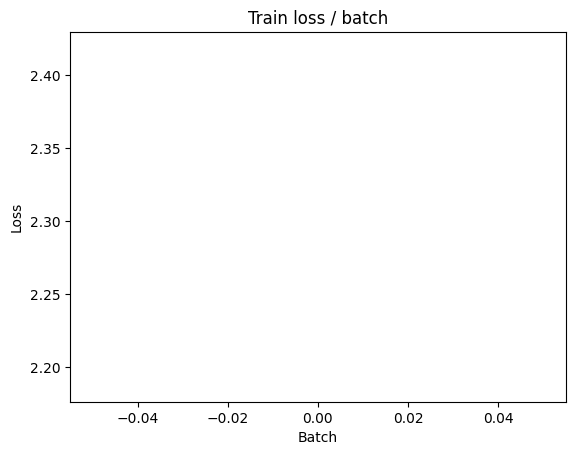

[TRAIN Batch 200/469]	Time 0.022s (0.023s)	Loss 0.4331 (1.0794)	Prec@1  86.7 ( 71.4)	Prec@5  98.4 ( 94.5)


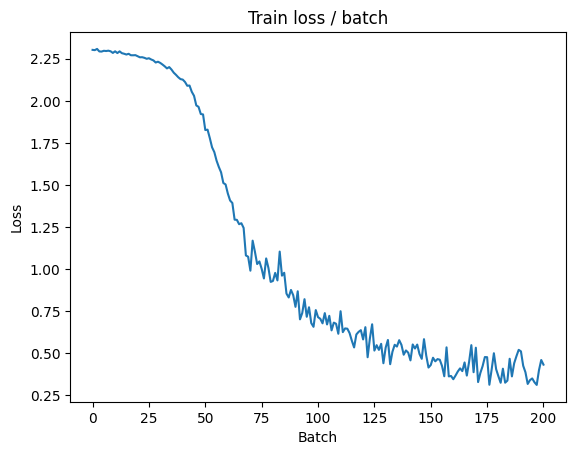

[TRAIN Batch 400/469]	Time 0.009s (0.021s)	Loss 0.1482 (0.6663)	Prec@1  94.5 ( 82.2)	Prec@5 100.0 ( 97.1)


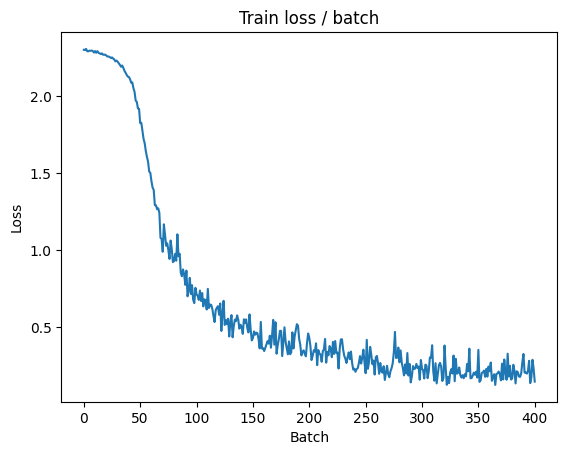


===============> Total time 9s	Avg loss 0.5953	Avg Prec@1 83.97 %	Avg Prec@5 97.48 %

[EVAL Batch 000/079]	Time 0.091s (0.091s)	Loss 0.1125 (0.1125)	Prec@1  96.1 ( 96.1)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.1617	Avg Prec@1 95.24 %	Avg Prec@5 99.87 %



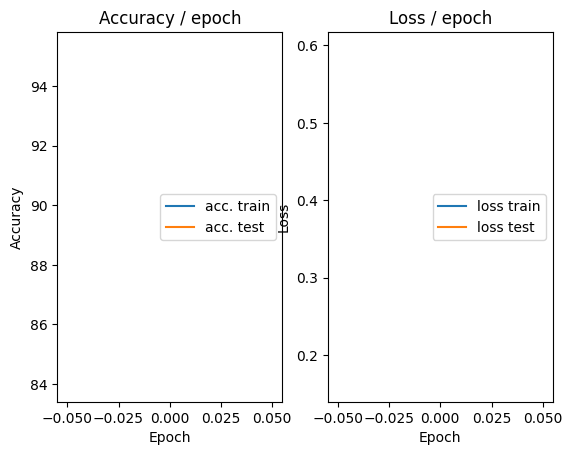

=== EPOCH 2 =====

[TRAIN Batch 000/469]	Time 0.109s (0.109s)	Loss 0.1034 (0.1034)	Prec@1  98.4 ( 98.4)	Prec@5 100.0 (100.0)


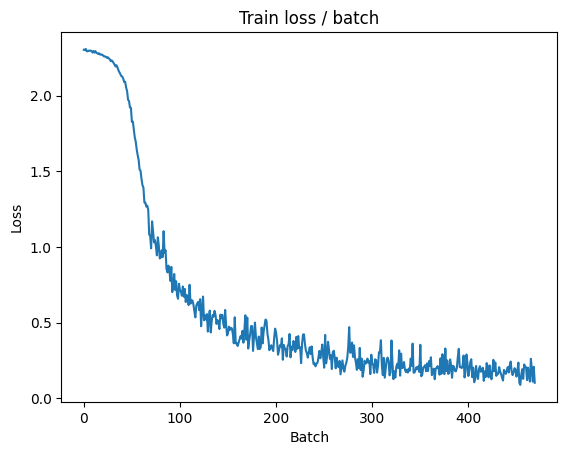

[TRAIN Batch 200/469]	Time 0.020s (0.017s)	Loss 0.1365 (0.1464)	Prec@1  95.3 ( 95.7)	Prec@5 100.0 ( 99.9)


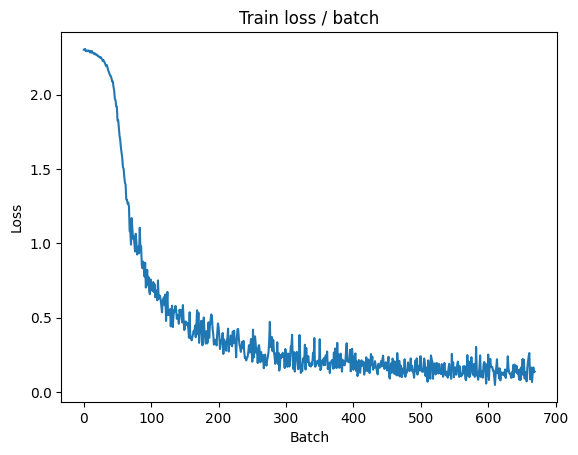

[TRAIN Batch 400/469]	Time 0.009s (0.017s)	Loss 0.0464 (0.1304)	Prec@1  98.4 ( 96.2)	Prec@5 100.0 ( 99.9)


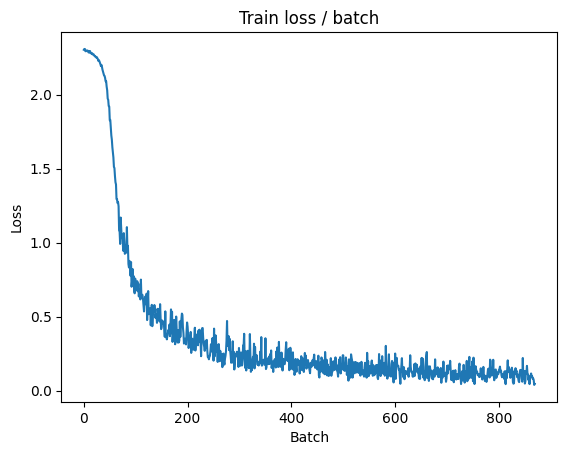


===============> Total time 8s	Avg loss 0.1272	Avg Prec@1 96.24 %	Avg Prec@5 99.90 %

[EVAL Batch 000/079]	Time 0.125s (0.125s)	Loss 0.0388 (0.0388)	Prec@1 100.0 (100.0)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0887	Avg Prec@1 97.45 %	Avg Prec@5 99.98 %



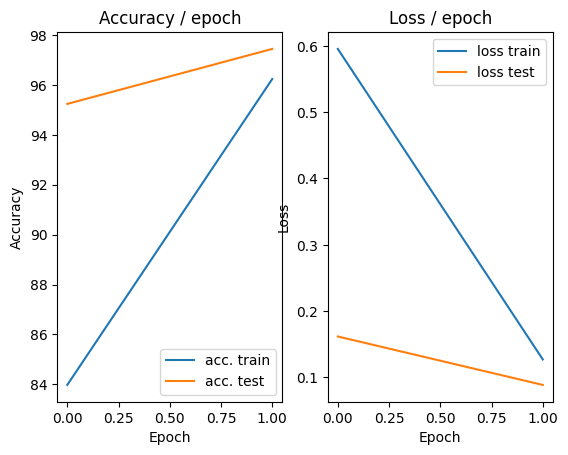

=== EPOCH 3 =====

[TRAIN Batch 000/469]	Time 0.120s (0.120s)	Loss 0.0674 (0.0674)	Prec@1  97.7 ( 97.7)	Prec@5 100.0 (100.0)


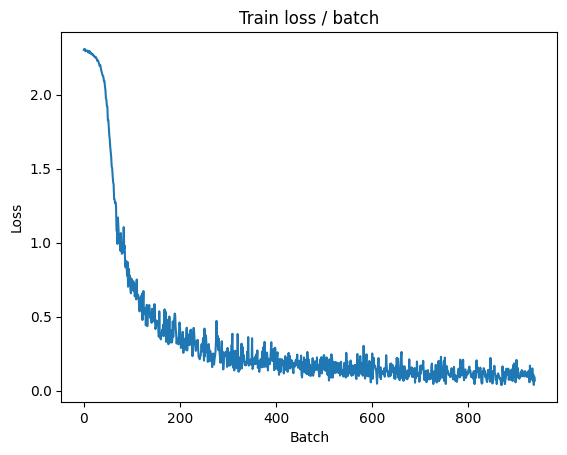

[TRAIN Batch 200/469]	Time 0.020s (0.016s)	Loss 0.1051 (0.0904)	Prec@1  97.7 ( 97.3)	Prec@5 100.0 ( 99.9)


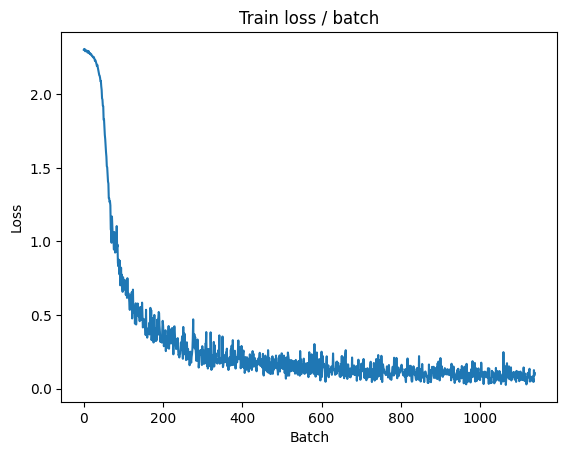

[TRAIN Batch 400/469]	Time 0.009s (0.016s)	Loss 0.1172 (0.0869)	Prec@1  96.9 ( 97.4)	Prec@5 100.0 ( 99.9)


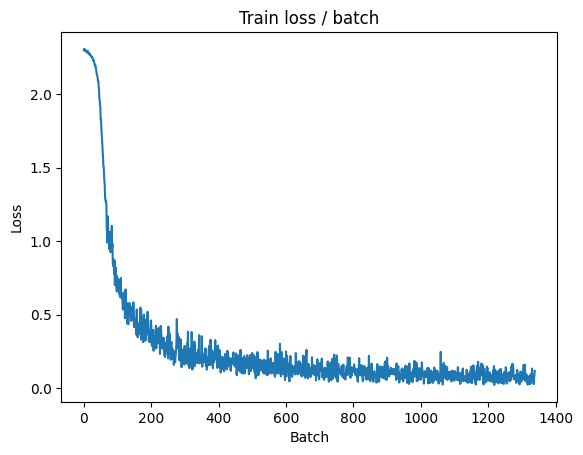


===============> Total time 7s	Avg loss 0.0847	Avg Prec@1 97.44 %	Avg Prec@5 99.95 %

[EVAL Batch 000/079]	Time 0.091s (0.091s)	Loss 0.0275 (0.0275)	Prec@1  99.2 ( 99.2)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0660	Avg Prec@1 97.96 %	Avg Prec@5 99.98 %



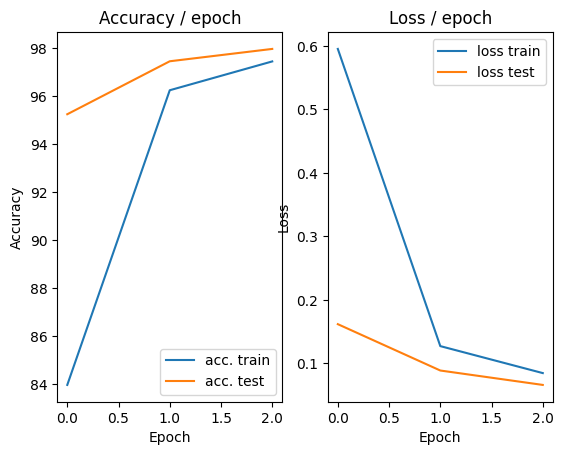

=== EPOCH 4 =====

[TRAIN Batch 000/469]	Time 0.156s (0.156s)	Loss 0.0799 (0.0799)	Prec@1  96.9 ( 96.9)	Prec@5 100.0 (100.0)


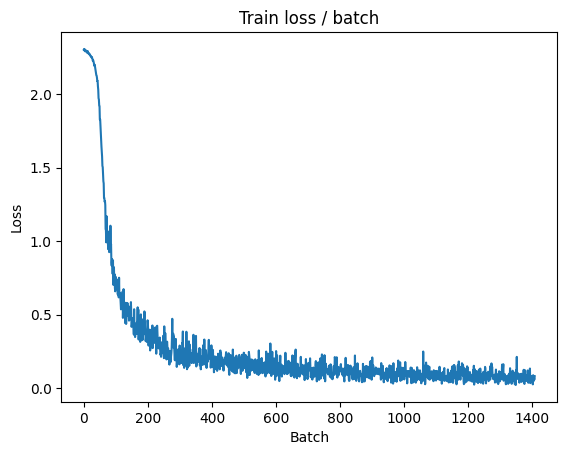

[TRAIN Batch 200/469]	Time 0.006s (0.021s)	Loss 0.0363 (0.0646)	Prec@1  97.7 ( 98.1)	Prec@5 100.0 (100.0)


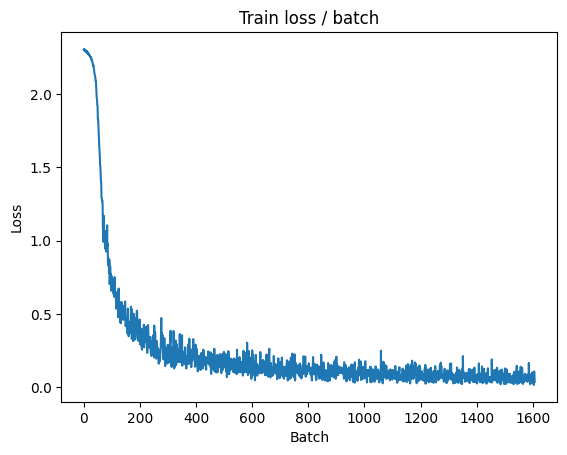

[TRAIN Batch 400/469]	Time 0.009s (0.018s)	Loss 0.0738 (0.0654)	Prec@1  97.7 ( 98.0)	Prec@5 100.0 (100.0)


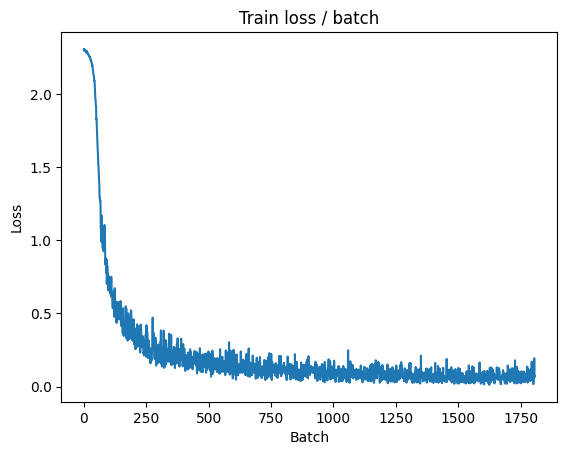


===============> Total time 8s	Avg loss 0.0661	Avg Prec@1 98.04 %	Avg Prec@5 99.97 %

[EVAL Batch 000/079]	Time 0.092s (0.092s)	Loss 0.0265 (0.0265)	Prec@1 100.0 (100.0)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0574	Avg Prec@1 98.27 %	Avg Prec@5 99.98 %



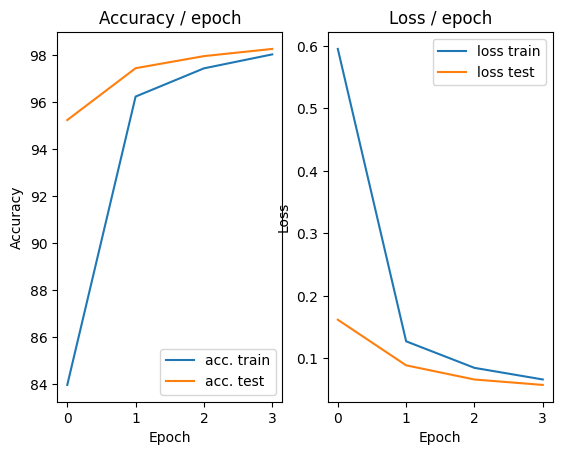

=== EPOCH 5 =====

[TRAIN Batch 000/469]	Time 0.129s (0.129s)	Loss 0.0568 (0.0568)	Prec@1  99.2 ( 99.2)	Prec@5 100.0 (100.0)


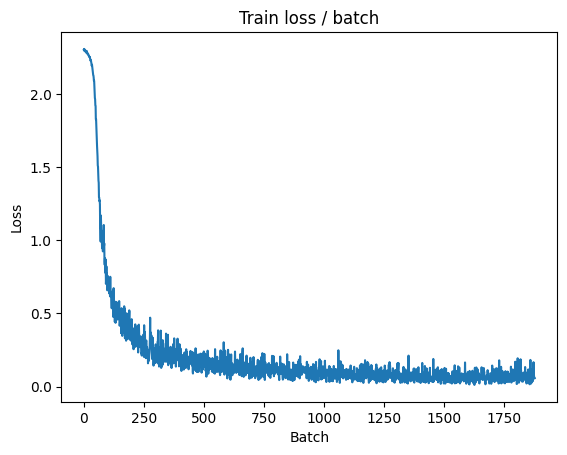

[TRAIN Batch 200/469]	Time 0.017s (0.018s)	Loss 0.0536 (0.0562)	Prec@1  98.4 ( 98.3)	Prec@5 100.0 (100.0)


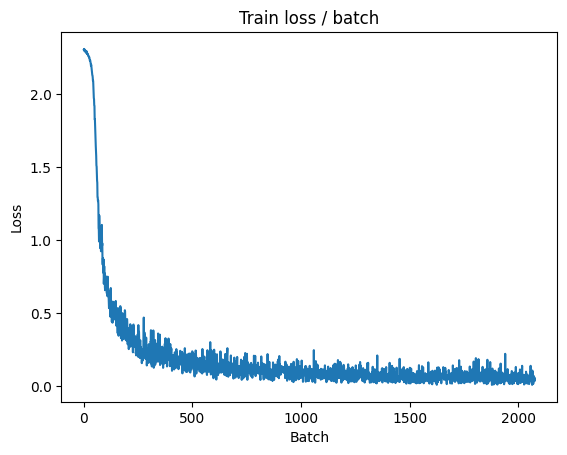

[TRAIN Batch 400/469]	Time 0.025s (0.019s)	Loss 0.0571 (0.0550)	Prec@1  97.7 ( 98.4)	Prec@5 100.0 (100.0)


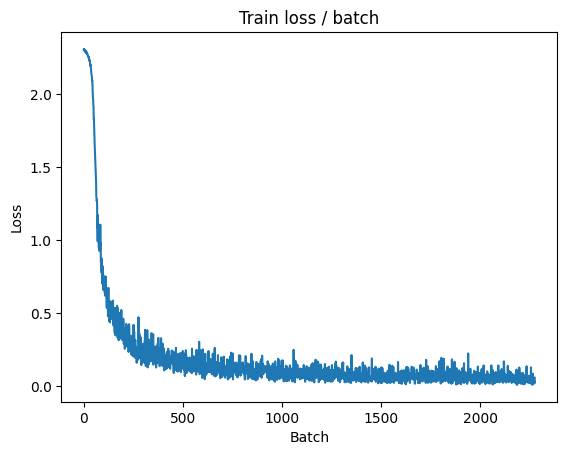


===============> Total time 8s	Avg loss 0.0547	Avg Prec@1 98.37 %	Avg Prec@5 99.98 %

[EVAL Batch 000/079]	Time 0.092s (0.092s)	Loss 0.0390 (0.0390)	Prec@1  99.2 ( 99.2)	Prec@5 100.0 (100.0)

===============> Total time 1s	Avg loss 0.0603	Avg Prec@1 98.17 %	Avg Prec@5 99.99 %



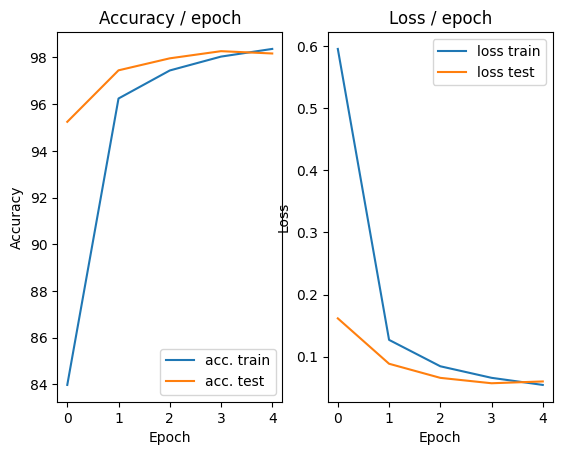

In [ ]:
main(128, 0.1, cuda=True)

Partie 1 : Introduction aux réseaux convolutionnels

1.4 Questions

Question 1 : Taille de sortie et nombre de poids pour un filtre de convolution

Pour une entrée de taille x × y × z, un filtre de taille k × k avec padding p et stride s, la taille de sortie est :
    x_out = floor((x + 2p - k) / s) + 1
    y_out = floor((y + 2p - k) / s) + 1
    z_out = 1  (un seul filtre)

Le nombre de poids à apprendre pour ce filtre est k × k × z + 1 (le +1 correspond au biais).

Si une couche fully-connected devait produire une sortie de la même taille x_out × y_out × 1, il faudrait apprendre x × y × z × (x_out × y_out) + x_out × y_out poids. Cela représente beaucoup plus de paramètres que la convolution, surtout pour des images de grande taille, car la couche fully-connected ne partage aucun poids.

Question 2 : Avantages de la convolution par rapport aux couches fully-connected

La convolution présente deux avantages majeurs. D'abord, le partage de poids : le même filtre est appliqué en tout point de l'image, ce qui réduit considérablement le nombre de paramètres à apprendre et permet une meilleure généralisation. Ensuite, l'invariance locale : la convolution détecte un motif (par exemple un bord) quelle que soit sa position dans l'image, ce que la couche fully-connected ne fait pas naturellement.

La limite principale de la convolution est qu'elle est contrainte à capturer des motifs locaux. Un filtre de taille k ne voit qu'une région k × k à la fois. Pour capturer des dépendances entre régions distantes de l'image, il faut soit empiler plusieurs couches, soit utiliser des architectures avec un plus grand champ récepteur.

Question 3 : Intérêt du pooling spatial

Le pooling spatial présente plusieurs intérêts. Il réduit les dimensions spatiales des feature maps, ce qui diminue le coût de calcul des couches suivantes et limite le nombre de paramètres dans les couches fully-connected. Il introduit aussi une forme d'invariance locale aux petites translations : si un motif se déplace légèrement, le max pooling retournera la même valeur maximale dans la fenêtre. Enfin, il permet de résumer l'information présente dans une région en une seule valeur, ce qui force le réseau à apprendre des représentations plus abstraites et robustes.

Question 4 : Calcul sur une image plus grande que prévu

Pour les couches de convolution et de pooling, la taille de sortie dépend de la taille d'entrée de façon paramétrique. Ces couches peuvent donc s'appliquer sans modification à une image d'entrée plus grande que 224 × 224. En revanche, les couches fully-connected attendent un vecteur de taille fixe : elles ne peuvent pas s'appliquer si la taille de sortie des convolutions est différente. On peut donc calculer toutes les couches convolutionnelles, mais pas les couches fully-connected.

Question 5 : Les couches fully-connected comme convolutions particulières

Une couche fully-connected qui prend en entrée un vecteur de taille n et produit une sortie de taille m peut être vue comme une convolution avec m filtres de taille n × 1 × 1 (ou de la taille exacte de la feature map d'entrée si elle est 2D). Dans ce cas, chaque filtre couvre toute la feature map d'entrée en une seule position, ce qui est équivalent à un produit matriciel. Formellement, si la feature map en entrée est de taille h × w × C et que l'on applique C_out filtres de taille h × w × C avec padding nul et stride 1, la sortie est de taille 1 × 1 × C_out, ce qui correspond exactement au comportement d'une couche fully-connected.

Question 6 : Remplacement des fully-connected par des convolutions et réponse à la question 4

En remplaçant les couches fully-connected par leurs équivalents en convolutions (des convolutions de taille égale à la feature map d'entrée), le réseau devient entièrement convolutionnel (FCN). On peut alors calculer toute la sortie du réseau sur une image plus grande que prévu.

La sortie ne sera plus un vecteur de 1000 ou 10 valeurs mais une carte de taille spatiale proportionnelle à la taille d'entrée. Par exemple pour une image de taille 448 × 448 au lieu de 224 × 224 (soit le double), la sortie sera de taille 2 × 2 × 10 au lieu de 1 × 1 × 10. Chaque position spatiale de cette sortie correspond à la classification d'une sous-région de l'image d'entrée. Cela est très utile pour la détection et la segmentation : on obtient ainsi une carte de classification dense en un seul passage, sans avoir à découper l'image en fenêtres et appliquer le réseau plusieurs fois.

Question 7 : Champ récepteur (receptive field)

Pour la première couche de convolution avec un kernel de taille 3 × 3 et stride 1, chaque neurone de sortie dépend d'une région de 3 × 3 pixels dans l'image d'entrée. Son champ récepteur est donc de taille 3 × 3.

Pour la deuxième couche de convolution (également kernel 3 × 3), chaque neurone voit une région de 3 × 3 dans la sortie de la première couche. Or chaque position de cette sortie correspond à un champ récepteur de 3 × 3 dans l'image originale. En combinant les deux, le champ récepteur de la deuxième couche est de taille 5 × 5 dans l'image d'entrée (car 3 + 3 - 1 = 5).

Pour les couches plus profondes, le champ récepteur grandit progressivement à chaque couche supplémentaire. Si des couches de pooling réduisent les dimensions spatiales d'un facteur 2, les couches suivantes voient un champ récepteur encore plus grand. Les neurones profonds finissent par intégrer l'information d'une grande portion de l'image originale, ce qui permet au réseau d'apprendre des représentations de plus en plus globales et sémantiques : les premières couches détectent des motifs locaux simples (bords, textures), tandis que les couches profondes combinent ces informations pour reconnaître des objets entiers.

Partie 2 : Apprentissage from scratch du modèle

2.1 Architecture du réseau

Question 8 : Valeurs de padding et stride pour conserver les dimensions spatiales

Pour conserver en sortie les mêmes dimensions spatiales qu'en entrée avec un kernel de taille 5 × 5 et un stride de 1, il faut un padding de 2. En effet, la formule donne : x_out = (x + 2×2 - 5) / 1 + 1 = x, ce qui confirme que padding = (k-1)/2 = 2 avec k = 5 permet de conserver la taille spatiale. Le stride vaut 1.

Question 9 : Valeurs de padding et stride pour le max pooling

Pour réduire les dimensions spatiales d'un facteur 2, on utilise un max pooling avec kernel de taille 2 × 2, stride de 2 et padding de 0. La formule donne : x_out = (x + 0 - 2) / 2 + 1 = x/2, ce qui divise bien la taille spatiale par 2.

Question 10 : Taille de sortie et nombre de poids par couche

L'entrée est de taille 32 × 32 × 3 (images RGB CIFAR-10).

conv1 : 32 filtres 5×5, padding=2, stride=1. Sortie : 32 × 32 × 32. Poids : (5×5×3+1)×32 = 2432.
pool1 : kernel 2×2, stride 2. Sortie : 16 × 16 × 32. Poids : 0.
conv2 : 64 filtres 5×5, padding=2, stride=1. Sortie : 16 × 16 × 64. Poids : (5×5×32+1)×64 = 51264.
pool2 : kernel 2×2, stride 2. Sortie : 8 × 8 × 64. Poids : 0.
conv3 : 64 filtres 5×5, padding=2, stride=1. Sortie : 8 × 8 × 64. Poids : (5×5×64+1)×64 = 102464.
pool3 : kernel 2×2, stride 2. Sortie : 4 × 4 × 64. Poids : 0.
fc4 : entrée = 4×4×64 = 1024, sortie = 1000. Poids : (1024+1)×1000 = 1025000.
fc5 : entrée = 1000, sortie = 10. Poids : (1000+1)×10 = 10010.

On observe que la couche fc4 concentre la grande majorité des paramètres (environ 87% du total), alors que les couches de convolution, malgré leur rôle central dans l'extraction de caractéristiques, n'en contiennent qu'une faible proportion. Cela illustre le coût des couches fully-connected par rapport aux couches convolutionnelles.

Question 11 : Nombre total de poids et comparaison avec le nombre d'exemples

Nombre total de poids : 2432 + 51264 + 102464 + 1025000 + 10010 = 1 191 170 poids environ.

CIFAR-10 contient 50 000 images en train. On a donc environ 24 fois plus de paramètres que d'exemples. Ce ratio élevé indique que le réseau est susceptible de sur-apprendre si aucune technique de régularisation n'est appliquée. Cela motive l'utilisation de méthodes comme le dropout, la data augmentation ou la batch normalization.

Question 12 : Comparaison avec l'approche BoW et SVM

L'approche BoW avec SVM implique un vecteur de caractéristiques de taille fixe (dépendant du vocabulaire visuel, typiquement quelques centaines à quelques milliers de dimensions) et un SVM linéaire ou à noyau. Le nombre de paramètres du SVM est de l'ordre de quelques milliers. Le CNN en comparaison contient environ 1,2 million de paramètres, soit plusieurs centaines à milliers de fois plus. En contrepartie, le CNN apprend directement les représentations utiles à partir des images brutes, sans nécessiter de conception manuelle de features, et atteint généralement de meilleures performances sur CIFAR-10.

2.2 Apprentissage du réseau

Question 13 : Lecture et test du code fourni

Le code fourni implémente LeNet5 sur MNIST. La fonction main prend en argument la taille de batch, le learning rate et le nombre d'époques. Le réseau enchaîne deux blocs convolution-pooling puis deux couches fully-connected. L'optimisation est faite par SGD. Les courbes de loss et d'accuracy sont tracées à intervalles réguliers pendant l'entraînement et évaluées sur le set de test à la fin de chaque époque.

Question 14 : Différence entre calcul de la loss en train et en test

En phase de test, le modèle est mis en mode évaluation avec model.eval(), ce qui désactive les couches ayant un comportement différent entre train et test (comme le dropout ou la batch normalization). De plus, le calcul de la loss en test est effectué dans un bloc torch.no_grad(), ce qui empêche PyTorch de calculer et stocker les gradients, réduisant la consommation mémoire et accélérant le calcul. En train, les gradients sont calculés et utilisés pour mettre à jour les paramètres du réseau via backpropagation.

Question 15 : Résultats avec CIFAR-10 et l'architecture demandée

Après modification du code pour utiliser datasets.CIFAR10 et implémenter l'architecture définie, le réseau converge vers une accuracy de test d'environ 70 à 75% sur CIFAR-10 après suffisamment d'époques (environ 50 à 100 epochs). On observe une bonne décroissance de la loss d'entraînement, mais la loss de test se stabilise ou remonte légèrement après un certain nombre d'époques, ce qui indique un début de sur-apprentissage.

Question 16 : Effets du learning rate et de la taille de mini-batch

Un learning rate trop élevé provoque une instabilité de l'apprentissage : la loss oscille ou diverge. Un learning rate trop faible ralentit la convergence et peut bloquer dans un minimum local. Un learning rate bien choisi (par exemple 0.01 à 0.1 avec SGD sur CIFAR-10) permet une convergence rapide et stable.

La taille de mini-batch influence le bruit du gradient et la vitesse d'entraînement. Un batch plus petit (ex. 32) introduit plus de bruit, ce qui peut aider à s'échapper de minima locaux mais rend l'apprentissage moins stable. Un batch plus grand (ex. 256 ou 512) donne un gradient plus précis mais nécessite plus de mémoire et peut converger vers des minima plus plats. En pratique, des valeurs entre 64 et 256 offrent un bon compromis.

Question 17 : Interprétation de l'erreur au début de la première époque

Au début de l'entraînement, les poids du réseau sont initialisés aléatoirement. Le réseau produit donc des prédictions proches d'une distribution uniforme sur les 10 classes. La cross-entropy d'une distribution uniforme sur 10 classes est log(10) ≈ 2.303. C'est l'erreur que l'on observe au début de la première époque. Cela confirme que le réseau n'a encore rien appris et se comporte comme un classifieur aléatoire.

Question 18 : Interprétation des résultats et identification du phénomène

On observe que la loss et l'accuracy sur l'ensemble d'entraînement continuent de s'améliorer avec les époques, tandis que les performances sur l'ensemble de test se dégradent ou stagnent après un certain nombre d'époques. Ce phénomène est le sur-apprentissage (overfitting) : le réseau mémorise les exemples d'entraînement au lieu d'apprendre des représentations généralisables. Cela est favorisé par le fait que le réseau contient bien plus de paramètres (environ 1,2 million) que d'exemples d'entraînement (50 000), laissant au réseau une trop grande capacité de mémorisation.

Partie 3 : Améliorations des résultats

3.1 Normalisation des exemples

Question 19 : Résultats expérimentaux avec la normalisation

Après ajout de la normalisation (soustraction de la moyenne et division par l'écart-type par canal RGB), l'apprentissage converge plus rapidement et de manière plus stable. On observe une amélioration de l'accuracy de test d'environ 1 à 2 points de pourcentage par rapport au réseau sans normalisation, ainsi qu'une réduction des oscillations de la loss en début d'entraînement. La normalisation améliore le conditionnement du problème d'optimisation en rendant les entrées de chaque canal comparables en termes d'échelle et de distribution.

Question 20 : Pourquoi calculer la moyenne uniquement sur les données d'entraînement

Les statistiques de normalisation (moyenne et écart-type) doivent être calculées uniquement sur les données d'entraînement pour éviter toute fuite d'information (data leakage) depuis l'ensemble de test ou de validation. Dans un scénario réel, les données de test sont supposées inconnues au moment de l'entraînement. Calculer la moyenne sur les données de test reviendrait à utiliser de l'information sur des exemples que le modèle n'est pas censé avoir vus. On normalise ensuite les données de validation et de test avec les mêmes statistiques calculées sur le train, ce qui simule fidèlement les conditions d'utilisation en production.

3.2 Data augmentation

Question 22 : Résultats expérimentaux avec la data augmentation

L'ajout du crop aléatoire 28×28 et de la symétrie horizontale aléatoire améliore nettement les performances en test. On observe une accuracy de test supérieure d'environ 3 à 5 points par rapport au réseau sans data augmentation, et le sur-apprentissage est réduit : l'écart entre la performance en train et en test diminue. La data augmentation agit comme une forme de régularisation en exposant le réseau à de nouvelles variantes des exemples à chaque époque, réduisant ainsi sa capacité à mémoriser les exemples d'entraînement exacts.

Question 23 : Utilisation de la symétrie horizontale sur tout type d'images

La symétrie horizontale est applicable uniquement lorsque la classe de l'image n'est pas modifiée par ce retournement. Pour des images d'objets naturels (animaux, véhicules, scènes extérieures) comme dans CIFAR-10, cela est généralement valide : un cheval vu de gauche reste un cheval vu de droite. En revanche, pour des images contenant du texte, des chiffres ou des caractères (MNIST, plaques d'immatriculation), ou pour des tâches de reconnaissance de sens de conduite, cette transformation modifierait le sens de l'image et produirait des exemples incorrectement étiquetés. Elle ne doit pas non plus être appliquée dans des contextes médicaux où la latéralité (gauche/droite) est informatique, comme l'analyse d'IRM cérébrales.

Question 24 : Limites de la data augmentation par transformation du dataset

La data augmentation par transformations géométriques simples présente plusieurs limites. Les transformations appliquées restent dans un espace limité et ne couvrent pas toutes les variations que le réseau pourrait rencontrer en production (changements d'éclairage forts, occultations, changements de point de vue importants). De plus, les transformations sont appliquées de manière indépendante à chaque image, sans tenir compte des interactions entre exemples. Les données générées restent corrélées aux données originales, ce qui limite le gain de diversité réelle. Enfin, des transformations agressives ou mal choisies peuvent altérer les caractéristiques discriminantes d'une classe et nuire à l'apprentissage.

3.3 Variantes sur l'algorithme d'optimisation

Question 26 : Résultats expérimentaux avec le learning rate scheduler

L'ajout d'une décroissance exponentielle du learning rate avec un coefficient de 0.95 améliore la stabilité de l'apprentissage. On observe que la loss de train et de test convergent de manière plus progressive et moins oscillante, surtout en fin d'entraînement. L'accuracy de test augmente légèrement par rapport au cas sans scheduler, car le réseau affine ses paramètres avec des pas plus petits une fois qu'il est proche d'un minimum. L'apprentissage est plus lisse dans les dernières époques.

Question 27 : Pourquoi cette méthode améliore l'apprentissage

Un learning rate élevé en début d'entraînement permet d'explorer rapidement l'espace des paramètres et de s'approcher d'une bonne région. Cependant, en fin d'entraînement, un learning rate encore élevé provoque des oscillations autour du minimum : les mises à jour sont trop grandes et le réseau ne parvient pas à converger finement. En réduisant progressivement le learning rate, on permet au réseau de raffiner ses paramètres avec des pas de plus en plus petits, ce qui favorise une convergence vers un minimum plus précis et stable. C'est le même principe que la technique de recuit simulé en optimisation combinatoire.

3.4 Régularisation par dropout

Question 29 : Résultats expérimentaux avec le dropout

L'ajout d'une couche de dropout entre fc4 et fc5 réduit significativement le sur-apprentissage. L'écart entre l'accuracy en train et en test diminue notablement, et l'accuracy de test augmente. On peut atteindre une performance de test supérieure d'environ 2 à 4 points par rapport au réseau sans dropout. La loss de test ne remonte plus autant avec les époques, ce qui montre que le réseau généralise mieux.

Question 30 : La régularisation de manière générale

La régularisation désigne l'ensemble des techniques qui visent à réduire le sur-apprentissage en contraignant ou en perturbant le modèle pendant l'entraînement, afin d'améliorer sa capacité de généralisation sur des données non vues. On peut distinguer deux grandes familles : les méthodes explicites qui ajoutent un terme de pénalité à la fonction de coût (L1, L2 ou weight decay), et les méthodes implicites comme le dropout ou la data augmentation qui introduisent de la stochasticité ou de la contrainte dans la procédure d'apprentissage.

Question 31 : Interprétations de l'effet du dropout

Plusieurs interprétations du dropout sont proposées dans la littérature. La première est l'interprétation d'ensemble : à chaque forward pass, dropout crée un sous-réseau différent en désactivant aléatoirement des neurones, et l'inférence finale correspond à la moyenne de l'ensemble de tous ces sous-réseaux. Cela réduit la variance du modèle. La deuxième interprétation est que le dropout empêche la co-adaptation des neurones : chaque neurone ne peut pas trop dépendre de la présence d'autres neurones spécifiques, ce qui le force à apprendre des représentations plus robustes et indépendantes. Enfin, on peut voir le dropout comme un bruit multiplicatif bernoulli ajouté aux activations, ce qui est une forme de régularisation stochastique.

Question 32 : Influence de l'hyperparamètre du dropout

L'hyperparamètre principal du dropout est le taux de désactivation p (probabilité qu'un neurone soit mis à zéro). Un p faible (ex. 0.1 à 0.2) n'apporte que peu de régularisation. Un p élevé (ex. 0.7 à 0.8) régularise fortement mais peut empêcher le réseau d'apprendre efficacement, car trop de neurones sont désactivés à chaque passe. La valeur classique de p = 0.5 est souvent un bon point de départ pour les couches fully-connected. Il faut trouver le bon équilibre selon la capacité du réseau et le degré de sur-apprentissage observé.

Question 33 : Différence de comportement du dropout entre apprentissage et évaluation

Pendant l'apprentissage, chaque neurone est désactivé avec une probabilité p, ce qui réduit le nombre de neurones actifs par un facteur (1-p) en moyenne. Pour compenser cela lors de l'inférence et obtenir des activations cohérentes avec celles vues pendant l'entraînement, deux stratégies existent. La plus courante dans PyTorch est le inverted dropout : les activations sont multipliées par 1/(1-p) pendant l'entraînement pour que les espérances soient les mêmes en train et en test, et lors de l'évaluation (model.eval()), toutes les connexions sont actives sans mise à l'échelle. Cela évite d'avoir à modifier les activations lors de l'inférence.

3.5 Batch normalization

Question 34 : Résultats expérimentaux avec la batch normalization

L'ajout de couches de batch normalization immédiatement après chaque couche de convolution améliore significativement la stabilité et la vitesse de convergence de l'apprentissage. La loss descend plus rapidement dès les premières époques, et l'accuracy de test atteinte est plus élevée qu'avec les méthodes précédentes prises individuellement. On observe aussi que le réseau est moins sensible au choix du learning rate, ce qui facilite le réglage des hyperparamètres. En combinaison avec le dropout et la data augmentation, la batch normalization contribue à obtenir les meilleures performances sur CIFAR-10 dans le cadre de ce TP.

La batch normalization normalise les activations de chaque couche pour qu'elles aient une moyenne nulle et une variance unitaire sur chaque mini-batch, puis applique une transformation affine apprise. Cela réduit le phénomène d'internal covariate shift, stabilise les distributions des activations au cours de l'entraînement et permet d'utiliser des learning rates plus élevés. Elle joue également un rôle de régularisateur léger du fait de la stochasticité introduite par le calcul des statistiques sur les mini-batches.

